# 피처 엔지니어링
차트 기반 파생변수 생성 + 시장 지표 + 피처 중요도 분석

In [1]:
# 셀 1 - 라이브러리 + MongoDB 연결
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

load_dotenv('../../collect_data/hyerim/.env')
client = MongoClient(os.getenv('MONGO_URI'))
db = client['data_hyerim']
print('MongoDB 연결 완료')

MongoDB 연결 완료


In [2]:
# 셀 2 - 데이터 불러오기
# 종목 ohlcv
cursor = db['stock_ohlcv_kospi200'].find({}, {'_id': 0})
df = pd.DataFrame(list(cursor))
df['date'] = pd.to_datetime(df['date']).dt.normalize()
df = df.sort_values(['stock_code', 'date']).reset_index(drop=True)

# 시장 지표
cursor_market = db['market_indicators'].find({}, {'_id': 0})
df_market = pd.DataFrame(list(cursor_market))
df_market['date'] = pd.to_datetime(df_market['date']).dt.normalize()
df_market = df_market.sort_values(['indicator', 'date']).reset_index(drop=True)

print(f'종목 shape: {df.shape}')
print(f'종목 수: {df["stock_code"].nunique()}')
print(f'시장 지표 shape: {df_market.shape}')
print(f'지표 목록: {df_market["indicator"].unique()}')

종목 shape: (199192, 12)
종목 수: 171
시장 지표 shape: (25067, 8)
지표 목록: ['dow' 'gold' 'kosdaq' 'kospi' 'nasdaq' 'sp500' 'usd_index' 'usd_krw'
 'vix' 'wti']


In [3]:
# 셀 3 - 시장 지표 피처 계산
def build_market_features(df_market: pd.DataFrame) -> pd.DataFrame:
    result = None

    for indicator, group in df_market.groupby('indicator'):
        group = group.copy().sort_values('date').reset_index(drop=True)

        tmp = pd.DataFrame()
        tmp['date'] = group['date']

        # 변화율
        tmp[f'{indicator}_change'] = group['close'].pct_change()

        # 20일 이평선 대비 추세 방향
        ma20 = group['close'].rolling(20).mean()
        tmp[f'{indicator}_trend'] = (group['close'] > ma20).astype(int)

        # 5일 연속 상승 여부
        tmp[f'{indicator}_up5'] = (
            group['close'].diff() > 0
        ).astype(int).rolling(5).sum().eq(5).astype(int)

        result = tmp if result is None else result.merge(tmp, on='date', how='outer')

    return result.sort_values('date').reset_index(drop=True)

df_mkt_feat = build_market_features(df_market)
print(f'시장 지표 피처 shape: {df_mkt_feat.shape}')
df_mkt_feat.head()

시장 지표 피처 shape: (2604, 31)


,date,dow_change,dow_trend,dow_up5,gold_change,gold_trend,gold_up5,kosdaq_change,kosdaq_trend,kosdaq_up5,...,usd_index_up5,usd_krw_change,usd_krw_trend,usd_krw_up5,vix_change,vix_trend,vix_up5,wti_change,wti_trend,wti_up5
0,2016-06-20,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0
1,2016-06-21,0.001396,0.0,0.0,-0.015116,0.0,0.0,-0.000581,0.0,0.0,...,0.0,-0.007882,0.0,0.0,0.005988,0.0,0.0,-0.010533,0.0,0.0
2,2016-06-22,-0.002743,0.0,0.0,-0.001968,0.0,0.0,-0.000537,0.0,0.0,...,0.0,-0.006685,0.0,0.0,0.145563,0.0,0.0,0.005732,0.0,0.0
3,2016-06-23,0.012949,0.0,0.0,-0.005363,0.0,0.0,-0.012584,0.0,0.0,...,0.0,-0.001476,0.0,0.0,-0.185168,0.0,0.0,0.019947,0.0,0.0
4,2016-06-24,-0.033886,0.0,0.0,0.046622,0.0,0.0,-0.047622,0.0,0.0,...,0.0,-0.007514,0.0,0.0,0.493333,0.0,0.0,-0.049292,0.0,0.0


In [13]:
# 셀 4 - 피처 엔지니어링 함수 (차트 + 도메인 지식)
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values('date').reset_index(drop=True)

    # -------------------------------------------------------
    # 이동평균선 (변경 없음)
    # -------------------------------------------------------
    for w in [5, 10, 20, 60, 120, 240]:
        df[f'ma{w}'] = df['close'].rolling(w).mean()

    for w in [10, 20, 60, 120]:
        df[f'ma{w}_gap'] = (df['close'] - df[f'ma{w}']) / (df[f'ma{w}'] + 1)

    df['ma_spread_5_60']  = (df['ma5']  - df['ma60']) / (df['ma60'] + 1)
    df['ma_spread_10_60'] = (df['ma10'] - df['ma60']) / (df['ma60'] + 1)

    df['is_uptrend'] = (
        (df['ma5'] > df['ma10']) &
        (df['ma10'] > df['ma20']) &
        (df['ma20'] > df['ma60'])
    ).astype(int)
    df['is_downtrend'] = (
        (df['ma5'] < df['ma10']) &
        (df['ma10'] < df['ma20']) &
        (df['ma20'] < df['ma60'])
    ).astype(int)

    df['ma10_break']      = (df['close'] < df['ma10']).astype(int)
    df['ma_cross_golden'] = (
        (df['ma5'] > df['ma10']) & (df['ma5'].shift(1) <= df['ma10'].shift(1))
    ).astype(int)
    df['ma_cross_dead'] = (
        (df['ma5'] < df['ma10']) & (df['ma5'].shift(1) >= df['ma10'].shift(1))
    ).astype(int)
    df['candle_above_ma60'] = (df['close'] > df['ma60']).astype(int)

    # -------------------------------------------------------
    # RSI (9일) - 변경 없음
    # -------------------------------------------------------
    delta = df['close'].diff()
    gain  = delta.clip(lower=0).ewm(com=8, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(com=8, adjust=False).mean()
    df['rsi_9'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

    df['rsi_above_70']       = (df['rsi_9'] > 70).astype(int)
    df['rsi_above_50']       = (df['rsi_9'] > 50).astype(int)
    df['rsi_exit_70']        = ((df['rsi_9'] < 70) & (df['rsi_9'].shift(1) >= 70)).astype(int)
    df['rsi_ma']             = df['rsi_9'].rolling(9).mean()
    df['rsi_touch_ma_count'] = (
        (df['rsi_9'] - df['rsi_ma']).abs() < 1.5
    ).astype(int).rolling(5).sum()

    # -------------------------------------------------------
    # [수정] MACD - 표준 파라미터 (12, 26, 9) 로 변경
    # 기존: span=25, signal span=60 → 비표준, macd와 signal 상관관계 0.90
    # -------------------------------------------------------
    ema12 = df['close'].ewm(span=12, adjust=False).mean()
    ema26 = df['close'].ewm(span=26, adjust=False).mean()  # 25 → 26
    df['macd']        = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()   # 60 → 9
    df['macd_hist']   = df['macd'] - df['macd_signal']

    # [추가] 정규화된 MACD (종목간 주가 수준 차이 제거)
    df['macd_hist_norm']   = df['macd_hist']   / (df['close'] + 1)
    df['macd_signal_norm'] = df['macd_signal'] / (df['close'] + 1)

    df['macd_uptrend']    = (df['macd'] > df['macd_signal']).astype(int)
    df['macd_above_zero'] = (df['macd'] > 0).astype(int)
    df['macd_near_zero']  = (
        df['macd'].abs() < df['macd'].rolling(20).std() * 0.3
    ).astype(int)

    # -------------------------------------------------------
    # 볼린저밴드 - 변경 없음
    # -------------------------------------------------------
    df['bb_mid']   = df['close'].rolling(20).mean()
    df['bb_std']   = df['close'].rolling(20).std()
    df['bb_upper'] = df['bb_mid'] + 2 * df['bb_std']
    df['bb_lower'] = df['bb_mid'] - 2 * df['bb_std']
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / (df['bb_mid'] + 1)
    df['bb_pct']   = (df['close'] - df['bb_lower']) / (
        df['bb_upper'] - df['bb_lower'] + 1
    )
    df['bb_upper_break']   = (df['close'] > df['bb_upper']).astype(int)
    df['bb_lower_support'] = (df['close'] <= df['bb_lower']).astype(int)

    # -------------------------------------------------------
    # 일목균형표 - cloud_thickness 제거 (ma_convergence와 0.87 상관)
    # -------------------------------------------------------
    high9  = df['high'].rolling(9).max()
    low9   = df['low'].rolling(9).min()
    high26 = df['high'].rolling(26).max()
    low26  = df['low'].rolling(26).min()
    high52 = df['high'].rolling(52).max()
    low52  = df['low'].rolling(52).min()

    df['ichi_conversion'] = (high9  + low9)  / 2
    df['ichi_base']       = (high26 + low26) / 2
    df['ichi_span_a']     = (df['ichi_conversion'] + df['ichi_base']) / 2
    df['ichi_span_b']     = (high52 + low52) / 2

    cloud_top    = df[['ichi_span_a', 'ichi_span_b']].max(axis=1)
    cloud_bottom = df[['ichi_span_a', 'ichi_span_b']].min(axis=1)

    df['ichi_above_cloud']      = (df['close'] > cloud_top).astype(int)
    df['ichi_below_cloud']      = (df['close'] < cloud_bottom).astype(int)
    df['ichi_in_cloud']         = (
        (df['close'] >= cloud_bottom) & (df['close'] <= cloud_top)
    ).astype(int)
    df['cloud_green']           = (df['ichi_span_a'] > df['ichi_span_b']).astype(int)
    # cloud_thickness 삭제 - feature_cols에서도 제외
    df['ichi_conversion_cross'] = (
        (df['ichi_conversion'] > df['ichi_base']) &
        (df['ichi_conversion'].shift(1) <= df['ichi_base'].shift(1))
    ).astype(int)

    # -------------------------------------------------------
    # 피보나치, 추세/지지저항, 캔들, 거래량 - 변경 없음
    # -------------------------------------------------------
    roll_high = df['high'].rolling(60).max()
    roll_low  = df['low'].rolling(60).min()
    fib_range = roll_high - roll_low

    df['fib_786_support'] = df['close'].between(
        roll_high - fib_range * 0.786 * 0.99,
        roll_high - fib_range * 0.786 * 1.01
    ).astype(int)
    df['fib_618_level'] = df['close'].between(
        roll_high - fib_range * 0.618 * 0.99,
        roll_high - fib_range * 0.618 * 1.01
    ).astype(int)
    df['fib_500_level'] = df['close'].between(
        roll_high - fib_range * 0.500 * 0.99,
        roll_high - fib_range * 0.500 * 1.01
    ).astype(int)

    prev_high = df['high'].shift(1).rolling(20).max()
    df['prev_high_break'] = (df['close'] > prev_high).astype(int)
    df['prev_high_fail']  = (
        (df['high'] >= prev_high * 0.99) & (df['close'] < prev_high)
    ).astype(int)

    df['higher_high'] = (df['high'] > df['high'].shift(1)).astype(int)
    df['higher_low']  = (df['low']  > df['low'].shift(1)).astype(int)
    df['lower_high']  = (df['high'] < df['high'].shift(1)).astype(int)

    prev_low = df['low'].rolling(10).min().shift(1)
    df['double_bottom'] = (df['low'] > prev_low).astype(int)

    candle_range = df['high'] - df['low'] + 1
    df['body_ratio']       = abs(df['close'] - df['open']) / candle_range
    df['is_bullish']       = (df['close'] > df['open']).astype(int)
    df['is_bearish']       = (df['close'] < df['open']).astype(int)
    df['is_doji']          = (df['body_ratio'] < 0.1).astype(int)
    df['upper_wick_ratio'] = (df['high'] - df[['open','close']].max(axis=1)) / candle_range
    df['lower_wick_ratio'] = (df[['open','close']].min(axis=1) - df['low']) / candle_range

    prev_close = df['close'].shift(1)
    df['gap_up']        = (df['open'] > prev_close * 1.005).astype(int)
    df['gap_down']      = (df['open'] < prev_close * 0.995).astype(int)
    df['gap_fill_rate'] = (
        (df['close'] - df['open']) / (prev_close - df['open'] + 1e-9)
    ).clip(-1, 1)

    vol_ma20 = df['volume'].rolling(20).mean()
    df['vol_ratio_20']           = df['volume'] / (vol_ma20 + 1)
    df['vol_spike']              = (df['vol_ratio_20'] >= 2).astype(int)
    df['vol_up_with_price_up']   = (
        (df['volume'] > vol_ma20) & (df['close'] > df['close'].shift(1))
    ).astype(int)
    df['vol_down_with_price_up'] = (
        (df['volume'] < vol_ma20) & (df['close'] > df['close'].shift(1))
    ).astype(int)

    # -------------------------------------------------------
    # 도메인 지식 파생변수
    # -------------------------------------------------------
    df['ma_convergence'] = (
        (df['ma5'] - df['ma20']).abs() +
        (df['ma10'] - df['ma60']).abs()
    ) / (df['close'] + 1)

    df['short_trend_turn'] = (
        (df['ma5'] < df['ma5'].shift(1)) & (df['ma10'] > df['ma60'])
    ).astype(int)
    df['uptrend_with_volume'] = (
        (df['is_uptrend'] == 1) & (df['vol_ratio_20'] >= 1.5)
    ).astype(int)
    df['ma60_support'] = (
        (df['close'] > df['ma60']) &
        (df['low'] <= df['ma60'] * 1.01) &
        (df['close'] > df['open'])
    ).astype(int)
    df['rsi_cooling'] = (
        (df['rsi_9'] > 45) & (df['rsi_9'] < 60) &
        (df['rsi_9'].shift(5) > 65)
    ).astype(int)
    df['bb_squeeze'] = (
        df['bb_width'] < df['bb_width'].rolling(20).mean() * 0.8
    ).astype(int)
    df['ichi_cloud_breakout'] = (
        (df['ichi_above_cloud'] == 1) & (df['ichi_above_cloud'].shift(1) == 0)
    ).astype(int)
    df['macd_zero_cross'] = (
        (df['macd'] > 0) & (df['macd'].shift(1) <= 0)
    ).astype(int)
    df['reversal_candle'] = (
        (df['is_bullish'] == 1) & (df['is_bullish'].shift(1) == 0)
    ).astype(int)
    df['pullback_after_breakout'] = (
        (df['prev_high_break'].shift(3) == 1) &
        (df['close'] < df['close'].shift(1)) &
        (df['close'] > df['ma10'])
    ).astype(int)

    prev_low_20 = df['low'].rolling(20).min().shift(5)
    df['double_bottom_confirm'] = (
        (df['low'] > prev_low_20) &
        (df['close'] > df['open']) &
        (df['vol_ratio_20'] >= 1.2)
    ).astype(int)
    df['rsi_macd_buy'] = (
        (df['rsi_9'] > 50) & (df['rsi_9'] < 70) &
        (df['macd_uptrend'] == 1) &
        (df['macd_above_zero'] == 1)
    ).astype(int)
    df['vol_surge_bullish'] = (
        (df['vol_spike'] == 1) & (df['is_bullish'] == 1)
    ).astype(int)
    df['gap_up_hold'] = (
        (df['gap_up'] == 1) & (df['close'] > df['open'])
    ).astype(int)
    df['convergence_vol_surge'] = (
        (df['ma_convergence'] < df['ma_convergence'].rolling(20).mean() * 0.5) &
        (df['vol_ratio_20'] >= 2.0)
    ).astype(int)

    # -------------------------------------------------------
    # [신규 추가] ATR - 변동성 기반 손절 수준
    # -------------------------------------------------------
    tr = pd.concat([
        df['high'] - df['low'],
        (df['high'] - df['close'].shift(1)).abs(),
        (df['low']  - df['close'].shift(1)).abs()
    ], axis=1).max(axis=1)
    df['atr_14']    = tr.ewm(span=14, adjust=False).mean()
    df['atr_ratio'] = df['atr_14'] / (df['close'] + 1)
    # 60일 롤링 분위수: "지금 변동성이 과거 대비 상위 몇 %인가"
    df['atr_pct60'] = df['atr_ratio'].rolling(60).rank(pct=True)
    # feature_cols에서 atr_ratio 대신 atr_pct60 사용

    # -------------------------------------------------------
    # [신규 추가] ADX - 추세 강도 (25 이상이면 추세 유효)
    # -------------------------------------------------------
    high_diff = df['high'].diff()
    low_diff  = df['low'].diff().abs()

    plus_dm  = np.where((high_diff > low_diff) & (high_diff > 0), high_diff, 0.0)
    minus_dm = np.where((low_diff > high_diff) & (low_diff > 0), low_diff, 0.0)

    atr_14_raw = pd.Series(tr).ewm(span=14, adjust=False).mean()
    plus_di    = 100 * pd.Series(plus_dm).ewm(span=14, adjust=False).mean() / (atr_14_raw + 1e-9)
    minus_di   = 100 * pd.Series(minus_dm).ewm(span=14, adjust=False).mean() / (atr_14_raw + 1e-9)
    dx         = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-9)

    df['adx_14']    = dx.ewm(span=14, adjust=False).mean()
    df['adx_trend'] = (df['adx_14'] > 25).astype(int)  # 추세 유효 여부

    # -------------------------------------------------------
    # [신규 추가] 골든크로스 경과일 (3~7일 구간이 핵심 매수 타이밍)
    # -------------------------------------------------------
    golden_event = df['ma_cross_golden']
    group_id     = (golden_event != golden_event.shift()).cumsum()
    df['days_since_golden'] = golden_event.groupby(group_id).cumsum()
    # 골든크로스 발생 후 1~10일 이내만 유효 신호로
    df['golden_window'] = df['days_since_golden'].between(1, 10).astype(int)

    # -------------------------------------------------------
    # [신규 추가] 조합 피처 - 실전 매수 패턴
    # -------------------------------------------------------
    # bb_squeeze 후 전고점 돌파 (횡보 탈출 가장 강한 신호)
    df['squeeze_breakout'] = (
        (df['bb_squeeze'].shift(1) == 1) &
        (df['prev_high_break'] == 1) &
        (df['vol_ratio_20'] >= 1.5)
    ).astype(int)

    # 60일선 위 눌림 후 거래량 수반 반등 (추세 추종 핵심 패턴)
    df['ma60_pullback_buy'] = (
        (df['candle_above_ma60'] == 1) &
        (df['close'].shift(1) < df['close'].shift(2)) &  # 전일 하락
        (df['close'] > df['close'].shift(1)) &            # 오늘 반등
        (df['vol_ratio_20'] >= 1.3)
    ).astype(int)

    return df

print('피처 함수 정의 완료')

피처 함수 정의 완료


In [14]:
# 셀 5 - 전종목 피처 계산
# [수정] target: 이진 분류 (매수 진입 vs 비진입)
# 이유: 관망 43%가 모델 편향의 근본 원인
#       실제 트레이딩에서 "언제 살 것인가"만 판단하면 됨
all_features = []
for code, group in df.groupby('stock_code'):
    try:
        feat = add_features(group)

        # 향후 5일 수익률
        feat['future_return'] = feat['close'].shift(-5) / feat['close'] - 1

        # [수정] 이진 분류: 5일 후 +3% 초과 → 매수(1), 나머지 → 비매수(0)
        # 기존 2.5% → 3%로 상향 (신호 품질 향상)
        feat['target'] = (feat['future_return'] > 0.03).astype(int)

        all_features.append(feat)
    except Exception as e:
        print(f'[skip] {code}: {e}')

df_all = pd.concat(all_features, ignore_index=True)
df_all['date'] = pd.to_datetime(df_all['date']).dt.normalize()

print(f'전종목 피처 계산 완료: {df_all.shape}')
print(f'\ntarget 분포:')
print(df_all['target'].value_counts())
print(f'\n비율:')
for t, label in zip([0, 1], ['비매수', '매수']):
    cnt = (df_all['target'] == t).sum()
    print(f'{label}: {cnt:,}건 ({cnt/len(df_all)*100:.1f}%)')

전종목 피처 계산 완료: (199192, 109)

target 분포:
target
0    147542
1     51650
Name: count, dtype: int64

비율:
비매수: 147,542건 (74.1%)
매수: 51,650건 (25.9%)


In [15]:
# 셀 6 - 시장 지표 조인
df_merged = df_all.merge(df_mkt_feat, on='date', how='left')
print(f'시장 지표 조인 완료: {df_merged.shape}')
df_merged.head()

시장 지표 조인 완료: (199192, 139)


,stock_code,date,close,collected_at,high,interval,low,open,source,trade_value,...,usd_index_up5,usd_krw_change,usd_krw_trend,usd_krw_up5,vix_change,vix_trend,vix_up5,wti_change,wti_trend,wti_up5
0,000100,2021-06-18,56077,2026-06-17 13:19:34.836,56077,1day,55200,55463,kis,18207998900,...,0.0,0.001405,1.0,0.0,0.166197,1.0,0.0,0.008446,1.0,0.0
1,000100,2021-06-21,55376,2026-06-17 13:19:34.835,55551,1day,54938,55463,kis,16939607700,...,0.0,0.000626,1.0,0.0,-0.135749,1.0,0.0,0.028197,1.0,0.0
2,000100,2021-06-22,55463,2026-06-17 13:19:34.835,55726,1day,55200,55288,kis,8127657700,...,0.0,-0.003447,1.0,0.0,-0.068753,0.0,0.0,-0.008146,1.0,0.0
3,000100,2021-06-23,55025,2026-06-17 13:19:34.835,55639,1day,54938,55551,kis,15206258700,...,0.0,0.001920,1.0,0.0,-0.020408,0.0,0.0,0.000274,1.0,0.0
4,000100,2021-06-24,55288,2026-06-17 13:19:34.835,55463,1day,55025,55200,kis,9393488600,...,0.0,0.000088,1.0,0.0,-0.021446,0.0,0.0,0.003010,1.0,0.0


In [16]:
# 셀 7 - 수급 데이터 조인 (수집 완료 시)
try:
    cursor_inv = db['investor_trend'].find({}, {'_id': 0})
    df_inv = pd.DataFrame(list(cursor_inv))
    df_inv['date']       = pd.to_datetime(df_inv['date']).dt.normalize()
    df_inv['stock_code'] = df_inv['stock_code'].astype(str).str.zfill(6)

    df_inv_pivot = df_inv.pivot_table(
        index=['stock_code', 'date'],
        values=['individual', 'foreign', 'institution'],
        aggfunc='sum'
    ).reset_index()

    # 당일 순매수 여부
    df_inv_pivot['foreign_net_buy']     = (df_inv_pivot['foreign']     > 0).astype(int)
    df_inv_pivot['institution_net_buy'] = (df_inv_pivot['institution'] > 0).astype(int)
    df_inv_pivot['individual_net_buy']  = (df_inv_pivot['individual']  > 0).astype(int)

    # 비율
    total = df_inv_pivot[['individual','foreign','institution']].abs().sum(axis=1) + 1
    df_inv_pivot['foreign_ratio']     = df_inv_pivot['foreign']     / total
    df_inv_pivot['institution_ratio'] = df_inv_pivot['institution'] / total

    # 외국인 + 기관 동시 순매수 (스마트머니)
    df_inv_pivot['smart_money'] = (
        (df_inv_pivot['foreign'] > 0) & (df_inv_pivot['institution'] > 0)
    ).astype(int)

    # merge
    inv_base_cols = [
        'foreign_net_buy', 'institution_net_buy', 'individual_net_buy',
        'foreign_ratio', 'institution_ratio', 'smart_money',
        'foreign', 'institution'
    ]
    df_merged = df_merged.merge(
        df_inv_pivot[['stock_code', 'date'] + inv_base_cols],
        on=['stock_code', 'date'], how='left'
    )

    # 외국인 3일 연속 순매수 (merge 후 계산)
    df_merged = df_merged.sort_values(['stock_code', 'date']).reset_index(drop=True)
    df_merged['foreign_buy_3d'] = df_merged.groupby('stock_code')['foreign_net_buy'].transform(
        lambda x: (x.rolling(3).sum() == 3).astype(int)
    )

    # 외국인 순매수 급증 (전일 대비 2배 이상)
    df_merged['foreign_surge'] = (
        (df_merged['foreign'] > 0) &
        (df_merged['foreign'] > df_merged.groupby('stock_code')['foreign'].shift(1) * 2)
    ).astype(int)

    inv_feature_cols = [
        'foreign_net_buy', 'institution_net_buy', 'individual_net_buy',
        'foreign_ratio', 'institution_ratio',
        'smart_money', 'foreign_buy_3d', 'foreign_surge'
    ]

    # 결측치 0으로
    for col in inv_feature_cols:
        df_merged[col] = df_merged[col].fillna(0)

    print(f'수급 조인 완료: {df_merged.shape}')
    print(f'smart_money 발생: {df_merged["smart_money"].sum():,}건')
    print(f'foreign_buy_3d:   {df_merged["foreign_buy_3d"].sum():,}건')
    print(f'foreign_surge:    {df_merged["foreign_surge"].sum():,}건')

except Exception as e:
    print(f'수급 데이터 없음: {e}')
    inv_feature_cols = []

수급 조인 완료: (199192, 149)
smart_money 발생: 42,875.0건
foreign_buy_3d:   35,649건
foreign_surge:    59,008건


In [17]:
# 셀 8 - 최종 피처셋 정의
# [수정] 제거: macd, macd_signal (macd_hist_norm으로 대체, 상관관계 0.90)
# [수정] 제거: cloud_thickness (ma_convergence와 0.87 상관)
# [추가] macd_hist_norm, macd_signal_norm, atr_ratio, adx_14, adx_trend,
#        squeeze_breakout, ma60_pullback_buy, golden_window

chart_feature_cols = [
    'ma10_gap', 'ma20_gap', 'ma60_gap', 'ma120_gap',
    'ma_spread_5_60', 'ma_spread_10_60',
    'is_uptrend', 'is_downtrend',
    'ma10_break', 'ma_cross_golden', 'ma_cross_dead', 'candle_above_ma60',
    'rsi_9', 'rsi_above_70', 'rsi_above_50', 'rsi_exit_70', 'rsi_touch_ma_count',
    # macd, macd_signal 삭제 → hist_norm, signal_norm으로 대체
    'macd_hist', 'macd_hist_norm', 'macd_signal_norm',
    'macd_uptrend', 'macd_above_zero', 'macd_near_zero', 'macd_zero_cross',
    'bb_pct', 'bb_width', 'bb_upper_break', 'bb_lower_support',
    'ichi_above_cloud', 'ichi_below_cloud', 'ichi_in_cloud',
    'cloud_green',  # cloud_thickness 삭제
    'ichi_conversion_cross',
    'fib_786_support', 'fib_618_level', 'fib_500_level',
    'prev_high_break', 'prev_high_fail',
    'higher_high', 'higher_low', 'lower_high', 'double_bottom',
    'body_ratio', 'is_bullish', 'is_bearish', 'is_doji',
    'upper_wick_ratio', 'lower_wick_ratio',
    'gap_up', 'gap_down', 'gap_fill_rate',
    'vol_ratio_20', 'vol_spike', 'vol_up_with_price_up', 'vol_down_with_price_up',
    'ma_convergence', 'short_trend_turn', 'uptrend_with_volume',
    'ma60_support', 'rsi_cooling', 'bb_squeeze',
    'ichi_cloud_breakout', 'reversal_candle',
    'pullback_after_breakout', 'double_bottom_confirm',
    'rsi_macd_buy', 'vol_surge_bullish', 'gap_up_hold', 'convergence_vol_surge',
    # [신규 추가]
    'atr_ratio',          # 변동성 기반 손절 수준
    'adx_14',             # 추세 강도
    'adx_trend',          # 추세 유효 여부 (ADX > 25)
    'golden_window',      # 골든크로스 후 1~10일
    'squeeze_breakout',   # 횡보 탈출 패턴
    'ma60_pullback_buy',  # 60일선 위 눌림 반등
]

market_feature_cols = [
    c for c in [
        'kospi_change', 'kospi_trend', 'kospi_up5',
        'nasdaq_change', 'nasdaq_trend', 'nasdaq_up5',
        'usd_krw_change', 'usd_krw_trend',
        'vix_change', 'vix_trend',
        'gold_change', 'gold_trend',
        'wti_change', 'wti_trend',
    ] if c in df_merged.columns
]

inv_feature_cols = [
    c for c in [
        'foreign_net_buy', 'institution_net_buy', 'individual_net_buy',
        'foreign_ratio', 'institution_ratio',
        'smart_money', 'foreign_buy_3d', 'foreign_surge'
    ] if c in df_merged.columns
]

final_feature_cols = chart_feature_cols + market_feature_cols + inv_feature_cols
final_feature_cols = [c for c in final_feature_cols if c in df_merged.columns]

print(f'차트 피처:  {len(chart_feature_cols)}개')
print(f'시장 지표:  {len(market_feature_cols)}개')
print(f'수급 피처:  {len(inv_feature_cols)}개')
print(f'총 피처 수: {len(final_feature_cols)}개')

차트 피처:  75개
시장 지표:  14개
수급 피처:  8개
총 피처 수: 97개


In [18]:
# 셀 9 - 최종 데이터셋 저장
df_final = df_merged.dropna(subset=final_feature_cols + ['target']).reset_index(drop=True)

X = df_final[final_feature_cols]
y = df_final['target']

print(f'최종 학습 데이터: {X.shape}')
print(f'target 분포:\n{y.value_counts()}')

# ohlcv + 피처 + target 모두 저장
save_cols = ['stock_code', 'stock_name', 'date', 'open', 'high', 'low', 'close', 'volume'] + final_feature_cols + ['target']
save_cols = [c for c in save_cols if c in df_final.columns]

df_final[save_cols].to_csv('dataset_final.csv', index=False)
print('dataset_final.csv 저장 완료')
print(f'저장 컬럼 수: {len(save_cols)}')

최종 학습 데이터: (172224, 97)
target 분포:
target
0    126402
1     45822
Name: count, dtype: int64
dataset_final.csv 저장 완료
저장 컬럼 수: 106


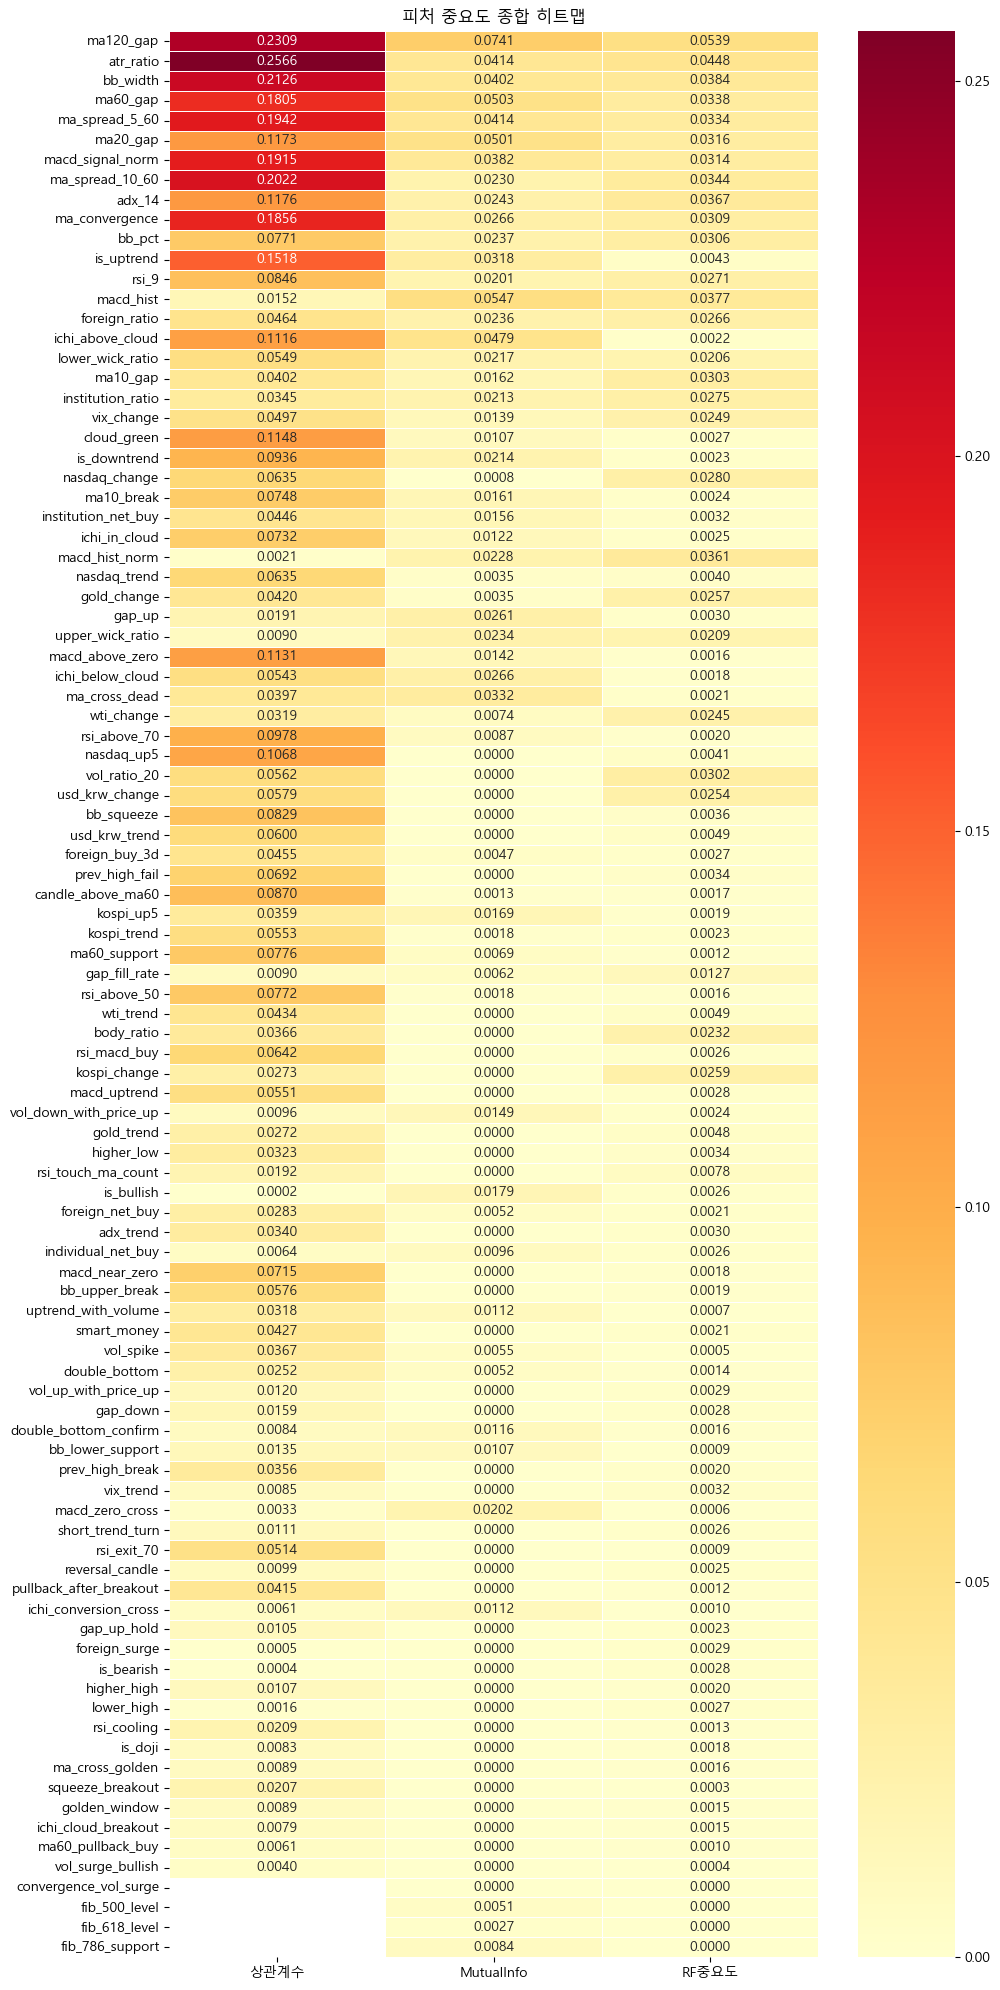


최종 피처 우선순위 (상위 20개):
                      총점
ma120_gap          286.0
atr_ratio          281.0
bb_width           276.0
ma60_gap           271.0
ma_spread_5_60     269.0
ma20_gap           265.0
macd_signal_norm   264.0
ma_spread_10_60    260.0
adx_14             260.0
ma_convergence     258.0
bb_pct             238.0
is_uptrend         237.0
rsi_9              228.0
macd_hist          216.0
foreign_ratio      213.0
ichi_above_cloud   209.0
lower_wick_ratio   205.0
ma10_gap           200.0
institution_ratio  196.0
vix_change         194.0


In [19]:
# 셀 10 - 삼성전자 기준 피처 중요도 분석
df_ss = df_final[df_final['stock_code'] == '005930'].copy()
X_ss = df_ss[final_feature_cols]
y_ss = df_ss['target']

# 상관계수
corr_result = (
    df_ss[final_feature_cols + ['target']]
    .corr()['target'].abs().drop('target')
    .sort_values(ascending=False)
)

# Mutual Information
mi_scores = mutual_info_classif(X_ss, y_ss, random_state=42)
mi_result = pd.Series(mi_scores, index=final_feature_cols).sort_values(ascending=False)

# RandomForest
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_ss, y_ss)
rf_importance = pd.Series(rf.feature_importances_, index=final_feature_cols).sort_values(ascending=False)

# 종합 점수
importance_df = pd.DataFrame({
    '상관계수':   corr_result,
    'MutualInfo': mi_result,
    'RF중요도':   rf_importance,
})
importance_df['총점'] = (
    importance_df['상관계수'].rank() +
    importance_df['MutualInfo'].rank() +
    importance_df['RF중요도'].rank()
)
importance_df = importance_df.sort_values('총점', ascending=False)

plt.figure(figsize=(10, 20))
sns.heatmap(
    importance_df[['상관계수', 'MutualInfo', 'RF중요도']],
    annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5
)
plt.title('피처 중요도 종합 히트맵')
plt.tight_layout()
plt.show()

print('\n최종 피처 우선순위 (상위 20개):')
print(importance_df[['총점']].head(20))

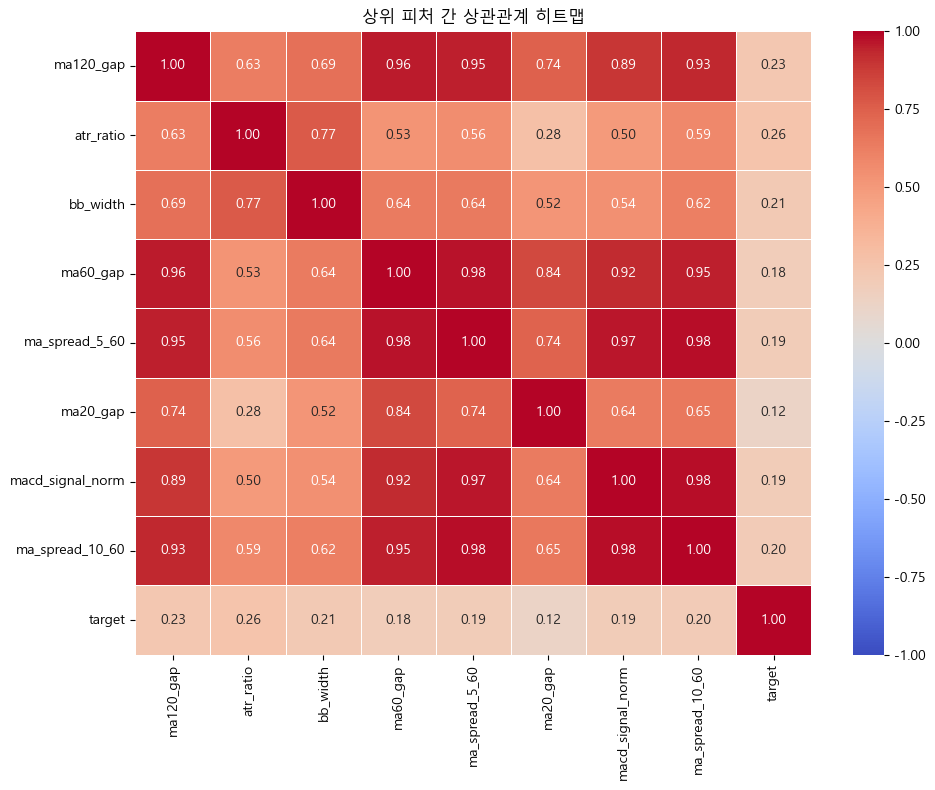

In [20]:
# 셀 11 - 상위 피처 간 상관관계 히트맵
top_features = importance_df.index[:8].tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_ss[top_features + ['target']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5
)
plt.title('상위 피처 간 상관관계 히트맵')
plt.tight_layout()
plt.show()

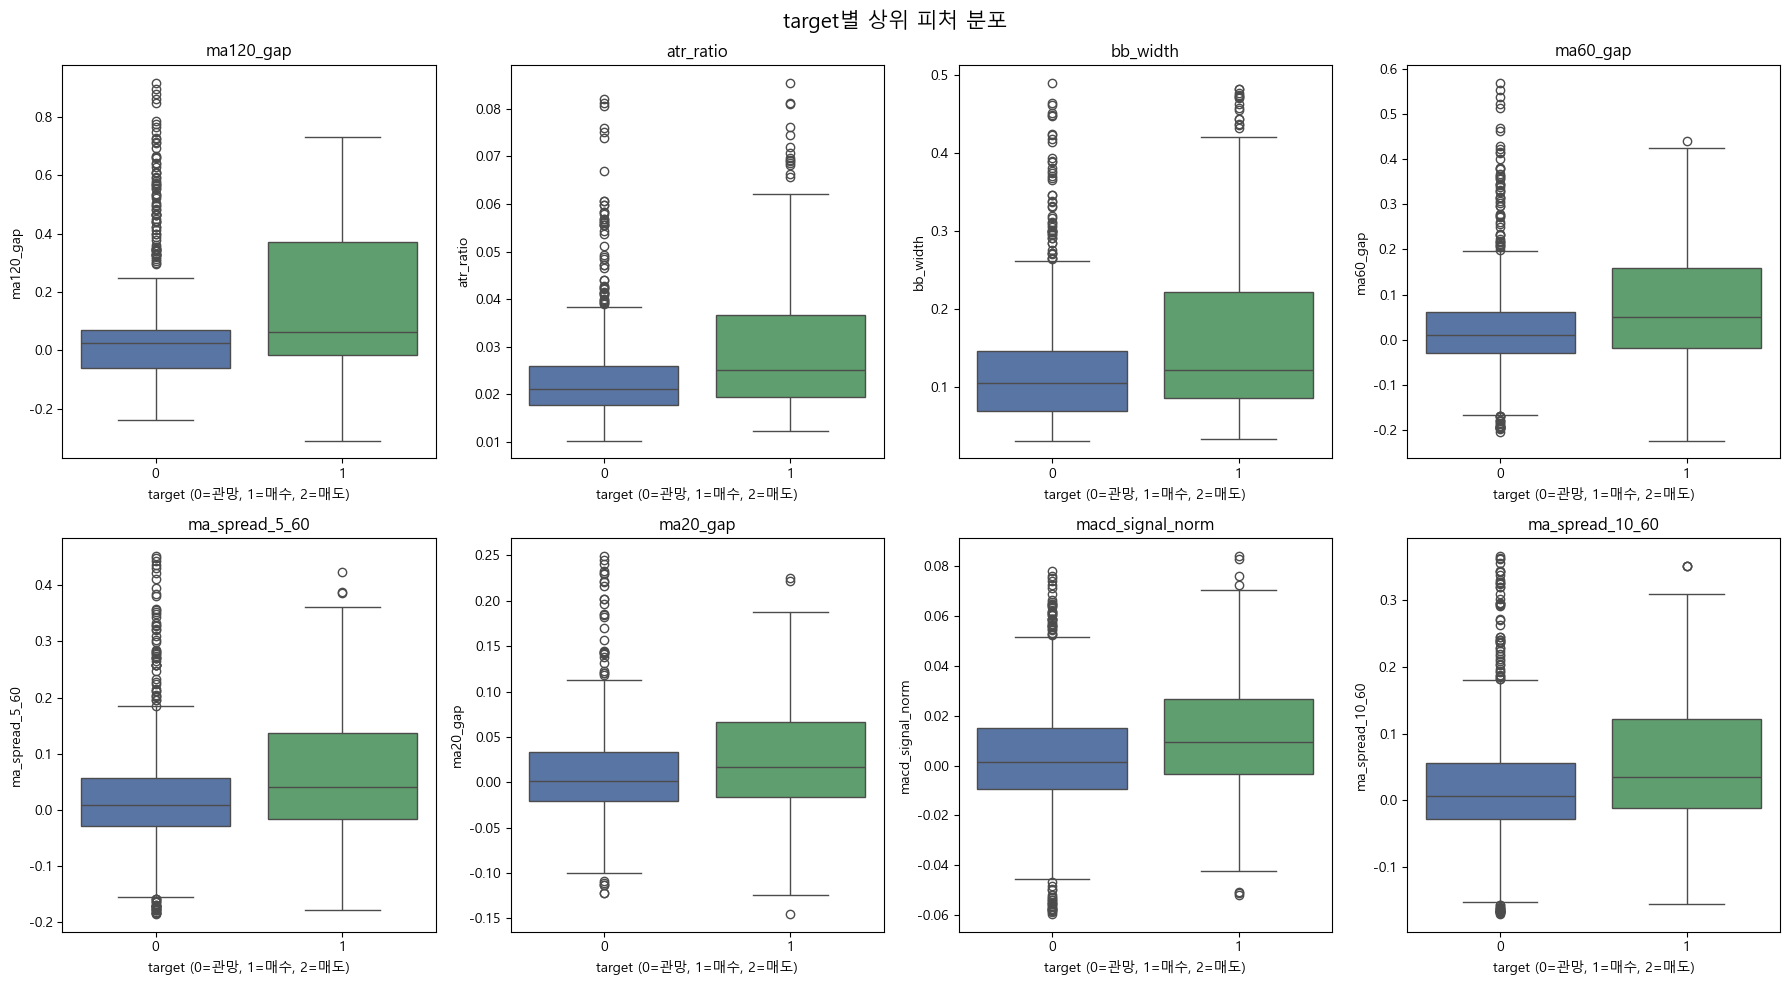

In [21]:
# 셀 12 - target별 상위 피처 분포 boxplot
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax, col in zip(axes.flatten(), top_features):
    sns.boxplot(
        data=df_ss, x='target', y=col, ax=ax,
        palette=['#4C72B0', '#55A868', '#DD8452']
    )
    ax.set_title(col)
    ax.set_xlabel('target (0=관망, 1=매수, 2=매도)')

plt.suptitle('target별 상위 피처 분포', fontsize=15)
plt.tight_layout()
plt.show()